In [19]:
import pandas as pd
import numpy as np
import joblib
import time
import json
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

###  load  the  preprocess data sets    

In [20]:
X_train = pd.read_csv("../data/X_train.csv")
X_test = pd.read_csv("../data/X_test.csv")
y_train = pd.read_csv("../data/y_train.csv").squeeze()
y_test = pd.read_csv("../data/y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (799815, 27)
X_test: (199954, 27)


###  hyperparameter  tunning    

In [21]:
# Tuning on the full training set would be slow; we tune on a representative
# 50,000-row sample, then fit the best configuration on the full training data.
tune_sample = X_train.sample(50000, random_state=42)
y_tune_sample = y_train.loc[tune_sample.index]

print("Tuning sample shape:", tune_sample.shape)

Tuning sample shape: (50000, 27)


### Define a results tracker   

In [22]:
results = {}
trained_models = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, train_time):
    start = time.time()
    y_pred = model.predict(X_te)
    predict_time = time.time() - start

    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    r2 = r2_score(y_te, y_pred)

    cv_sample = X_tr.sample(20000, random_state=42)
    cv_scores = cross_val_score(model, cv_sample, y_tr.loc[cv_sample.index],
                                 cv=5, scoring="r2", n_jobs=-1)

    results[name] = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "CV_R2_Mean": cv_scores.mean(),
        "CV_R2_Std": cv_scores.std(),
        "Train_Time_Sec": train_time,
        "Predict_Time_Sec": predict_time
    }
    trained_models[name] = model

    print(f"{name} — MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f} | CV R²: {cv_scores.mean():.4f}")
    return model

### Model 1: Linear Regression   

In [23]:
start = time.time()
lr = LinearRegression()
lr.fit(X_train, y_train)
train_time = time.time() - start

lr = evaluate_model("Linear Regression", lr, X_train, y_train, X_test, y_test, train_time)

Linear Regression — MAE: 0.3983 | RMSE: 0.4993 | R²: 0.9132 | CV R²: 0.9121


### Model 2: Decision Tree

In [24]:
dt_params = {
    "max_depth": [5, 8, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

dt_search = RandomizedSearchCV(DecisionTreeRegressor(random_state=42), dt_params,
                                n_iter=10, cv=3, scoring="r2", random_state=42, n_jobs=-1)
dt_search.fit(tune_sample, y_tune_sample)
print("Best Decision Tree params:", dt_search.best_params_)

start = time.time()
dt = DecisionTreeRegressor(**dt_search.best_params_, random_state=42)
dt.fit(X_train, y_train)
train_time = time.time() - start

dt = evaluate_model("Decision Tree", dt, X_train, y_train, X_test, y_test, train_time)

Best Decision Tree params: {'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 8}
Decision Tree — MAE: 0.4057 | RMSE: 0.5083 | R²: 0.9101 | CV R²: 0.9014


### Model 3: XGBoost

In [25]:
xgb_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 9],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, tree_method="hist", device="cuda"),
    xgb_params, n_iter=10, cv=3, scoring="r2", random_state=42, n_jobs=1
)
xgb_search.fit(tune_sample, y_tune_sample)
print("Best XGBoost params:", xgb_search.best_params_)

start = time.time()
xgb_model = XGBRegressor(**xgb_search.best_params_, random_state=42, tree_method="hist", device="cuda")
xgb_model.fit(X_train, y_train)
train_time = time.time() - start

xgb_model = evaluate_model("XGBoost", xgb_model, X_train, y_train, X_test, y_test, train_time)

Best XGBoost params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
XGBoost — MAE: 0.3993 | RMSE: 0.5005 | R²: 0.9128 | CV R²: 0.9084


### Model 4: LightGBM    

In [26]:
lgbm_params = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, -1],
    "num_leaves": [20, 31, 50],
    "subsample": [0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=42, verbose=-1, n_jobs=4),
    lgbm_params, n_iter=10, cv=3, scoring="r2", random_state=42, n_jobs=1
)
lgbm_search.fit(tune_sample, y_tune_sample)
print("Best LightGBM params:", lgbm_search.best_params_)

start = time.time()
lgbm_model = LGBMRegressor(**lgbm_search.best_params_, random_state=42, verbose=-1, n_jobs=4)
lgbm_model.fit(X_train, y_train)
train_time = time.time() - start

lgbm_model = evaluate_model("LightGBM", lgbm_model, X_train, y_train, X_test, y_test, train_time)

Best LightGBM params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05}
LightGBM — MAE: 0.3988 | RMSE: 0.4999 | R²: 0.9130 | CV R²: 0.9103


### Compile results into a comparison table   

In [27]:
results_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
results_df

,MAE,RMSE,R2,CV_R2_Mean,CV_R2_Std,Train_Time_Sec,Predict_Time_Sec
Linear Regression,0.398340,0.499273,0.913233,0.912066,0.002650,0.524644,0.014997
LightGBM,0.398827,0.499890,0.913018,0.910293,0.002913,1.603650,0.242516
XGBoost,0.399273,0.500507,0.912804,0.908431,0.003151,2.806199,0.039505
Decision Tree,0.405672,0.508254,0.910084,0.901400,0.003309,4.027188,0.033003


#### Bar chart comparison    

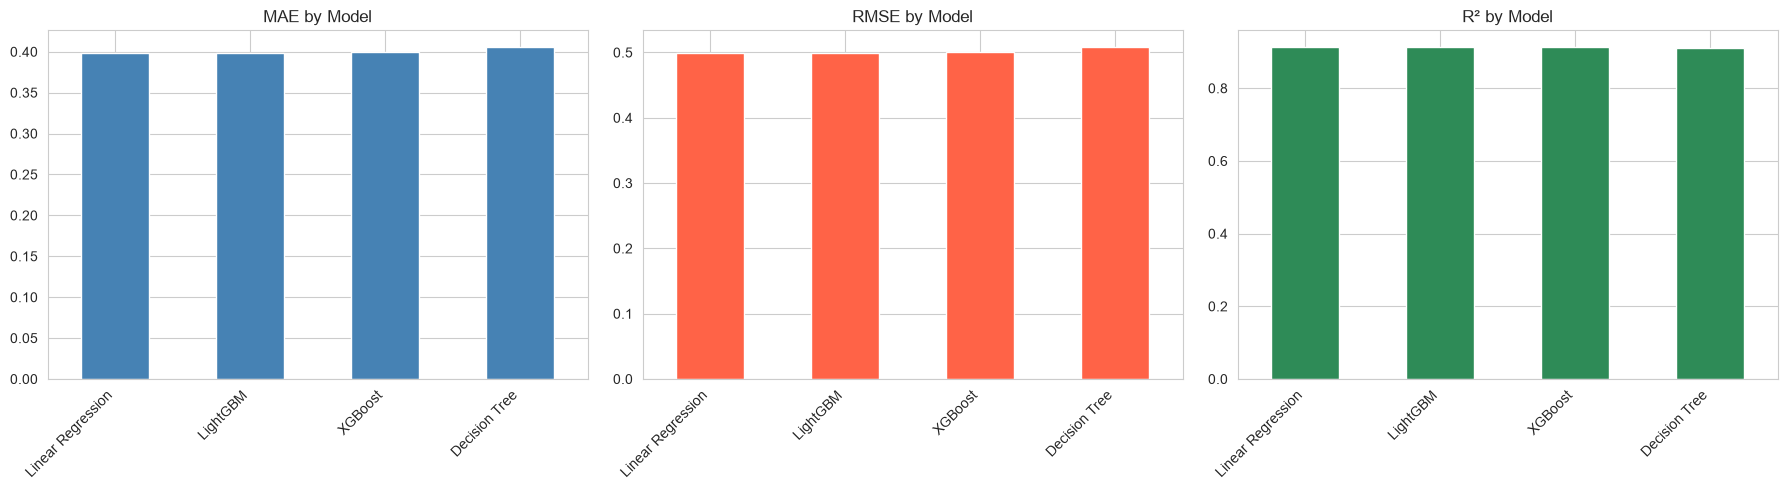

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

results_df["MAE"].plot(kind="bar", ax=axes[0], color="steelblue", title="MAE by Model")
results_df["RMSE"].plot(kind="bar", ax=axes[1], color="tomato", title="RMSE by Model")
results_df["R2"].plot(kind="bar", ax=axes[2], color="seagreen", title="R² by Model")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../reports/figures/12_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Training/prediction time comparison    

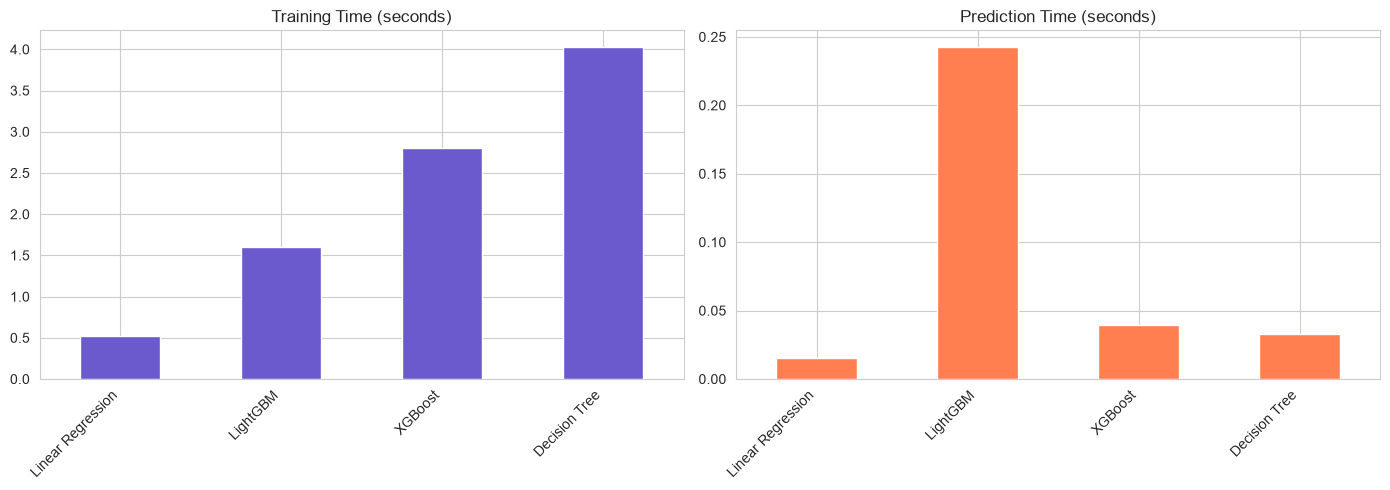

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df["Train_Time_Sec"].plot(kind="bar", ax=axes[0], color="slateblue", title="Training Time (seconds)")
results_df["Predict_Time_Sec"].plot(kind="bar", ax=axes[1], color="coral", title="Prediction Time (seconds)")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("../reports/figures/16_time_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Select the best model    

In [30]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f"Best model selected: {best_model_name}")
print(results_df.loc[best_model_name])

Best model selected: Linear Regression
MAE                 0.398340
RMSE                0.499273
R2                  0.913233
CV_R2_Mean          0.912066
CV_R2_Std           0.002650
Train_Time_Sec      0.524644
Predict_Time_Sec    0.014997
Name: Linear Regression, dtype: float64


### Actual vs Predicted plot   

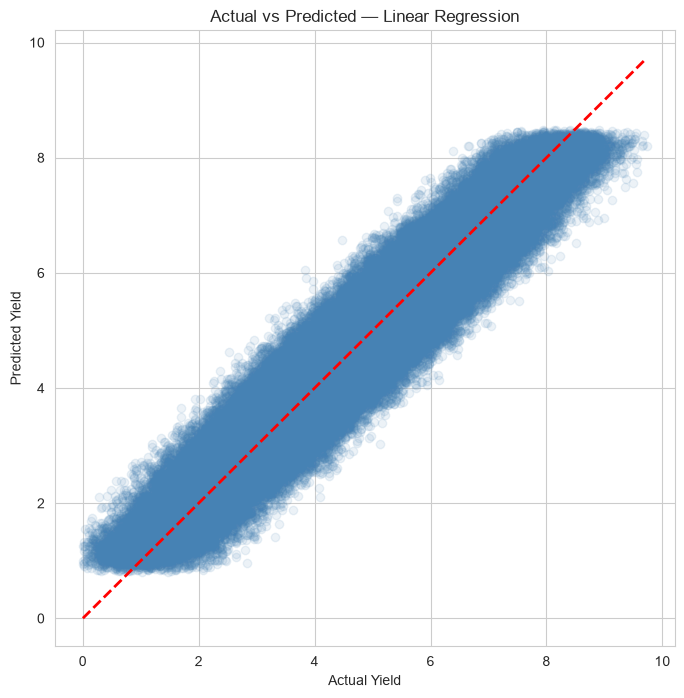

In [31]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.1, color="steelblue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title(f"Actual vs Predicted — {best_model_name}")
plt.savefig("../reports/figures/13_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

### Residual plot   

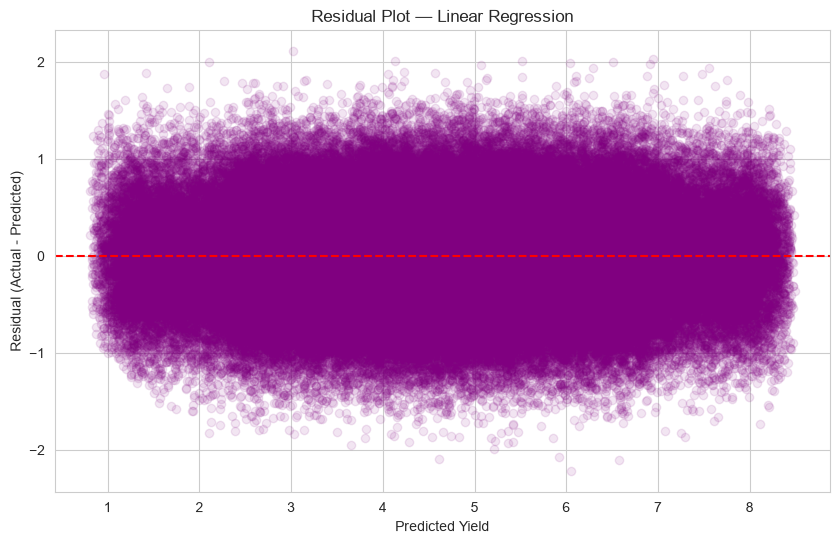

In [32]:
residuals = y_test - y_pred_best

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_best, residuals, alpha=0.1, color="purple")
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Yield")
plt.ylabel("Residual (Actual - Predicted)")
plt.title(f"Residual Plot — {best_model_name}")
plt.savefig("../reports/figures/14_residual_plot.png", dpi=150, bbox_inches="tight")
plt.show()

#### Error distribution   

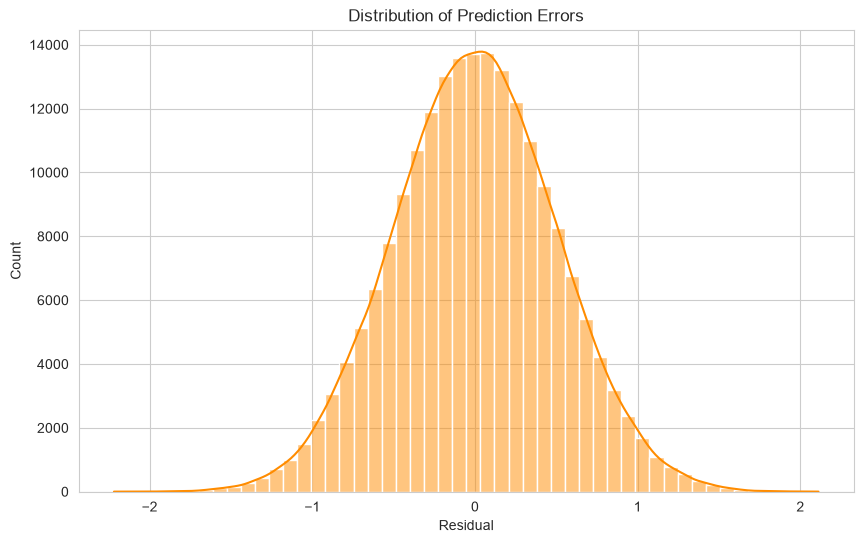

Mean residual: 0.0001097261115440002
Residual std: 0.49927378956936197


In [33]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50, color="darkorange")
plt.title("Distribution of Prediction Errors")
plt.xlabel("Residual")
plt.savefig("../reports/figures/15_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean residual:", residuals.mean())
print("Residual std:", residuals.std())

### Save all models and the best model   

In [34]:
os.makedirs("../models/trained", exist_ok=True)

joblib.dump(best_model, "../models/best_model.pkl")

for name, model in trained_models.items():
    filename = name.lower().replace(" ", "_")
    joblib.dump(model, f"../models/trained/{filename}.pkl")

results_df.to_csv("../reports/model_comparison.csv")

print(f"Best model ({best_model_name}) saved to ../models/best_model.pkl")
print("All trained models saved to ../models/trained/")

Best model (Linear Regression) saved to ../models/best_model.pkl
All trained models saved to ../models/trained/


###  Save summary   

In [35]:
final_summary = {
    "models_trained": list(trained_models.keys()),
    "models_excluded": {
        "Random Forest": "Excluded due to CPU/thermal constraints on local hardware during development",
        "Gradient Boosting": "Excluded to focus tuning effort on core model comparison within time constraints",
        "CatBoost": "Excluded to focus tuning effort on core model comparison within time constraints"
    },
    "best_model": best_model_name,
    "best_model_metrics": results_df.loc[best_model_name].to_dict(),
    "residual_mean": float(residuals.mean()),
    "residual_std": float(residuals.std()),
    "notes": (
        "All four evaluated models (Linear Regression, Decision Tree, XGBoost, LightGBM) "
        "clustered tightly around R²≈0.91, indicating the underlying relationship between "
        "features (primarily Rainfall_mm) and Yield_tons_per_hectare is close to linear. "
        f"{best_model_name} was selected as the best model, offering strong accuracy "
        "alongside full interpretability and fast inference — a practical choice for "
        "production deployment."
    )
}

with open("../reports/model_training_summary.json", "w") as f:
    json.dump(final_summary, f, indent=4)

final_summary

{'models_trained': ['Linear Regression',
  'Decision Tree',
  'XGBoost',
  'LightGBM'],
 'models_excluded': {'Random Forest': 'Excluded due to CPU/thermal constraints on local hardware during development',
  'Gradient Boosting': 'Excluded to focus tuning effort on core model comparison within time constraints',
  'CatBoost': 'Excluded to focus tuning effort on core model comparison within time constraints'},
 'best_model': 'Linear Regression',
 'best_model_metrics': {'MAE': 0.39833960635011706,
  'RMSE': 0.4992725531535405,
  'R2': 0.9132331845907836,
  'CV_R2_Mean': 0.9120660838280056,
  'CV_R2_Std': 0.002649696611140368,
  'Train_Time_Sec': 0.5246438980102539,
  'Predict_Time_Sec': 0.014997243881225586},
 'residual_mean': 0.0001097261115440002,
 'residual_std': 0.49927378956936197,
 'notes': 'All four evaluated models (Linear Regression, Decision Tree, XGBoost, LightGBM) clustered tightly around R²≈0.91, indicating the underlying relationship between features (primarily Rainfall_mm) 